In [3]:
import matplotlib.pyplot as plt
import numpy as np
import lab1package as lab
import pandas as pd
from scipy.stats import kurtosis, skew
import os

In [4]:
data = pd.read_hdf("wille_simulated_data.h5")
print(data)

           time (ns)  time series  time series, gain corrected   frequencies  \
0       0.000000e+00   303.602046                     1.325274  0.000000e+00   
1       2.000000e-10    31.563621                    -0.365384  2.000000e+04   
2       4.000000e-10   -17.823009                     0.296162  4.000000e+04   
3       6.000000e-10   -11.402631                    -0.175143  6.000000e+04   
4       8.000000e-10    -1.034442                     0.140914  8.000000e+04   
...              ...          ...                          ...           ...   
124996  2.499920e-05    15.370030                    -0.556035  2.499920e+09   
124997  2.499940e-05    -2.353323                     0.461037  2.499940e+09   
124998  2.499960e-05     0.452662                    -0.516828  2.499960e+09   
124999  2.499980e-05     1.942589                     0.287795  2.499980e+09   
125000  2.500000e-05   -33.583269                    -0.441640  2.500000e+09   

        HI voltage spectrum  gain patte

Data shape: (125001, 7)
Columns: ['time (ns)', 'time series', 'time series, gain corrected', 'frequencies', 'HI voltage spectrum', 'gain pattern', 'HI voltage spectrum, gain corrected']


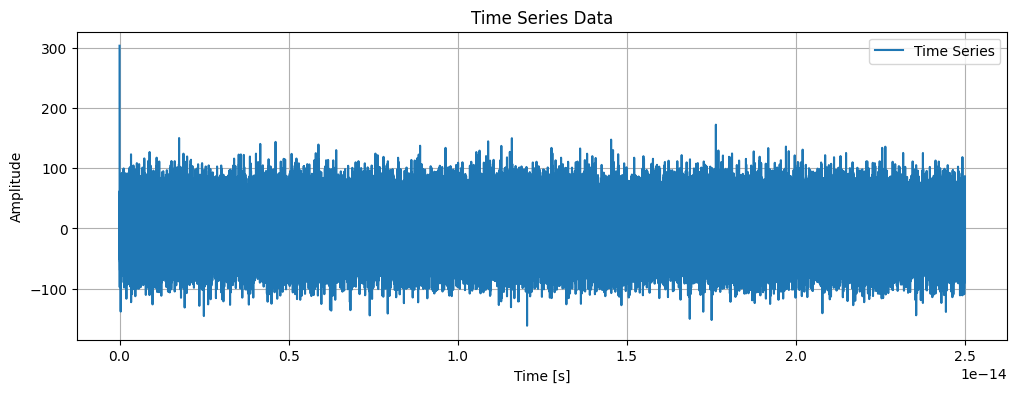

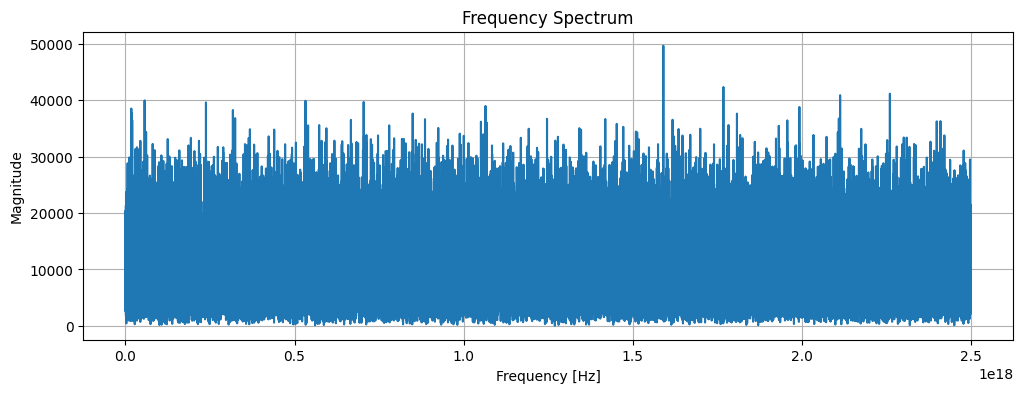

In [5]:
# Load data
data = pd.read_hdf("wille_simulated_data.h5")

# Check the structure
print("Data shape:", data.shape)
print("Columns:", data.columns.tolist())

# Extract time series data
time_series = data["time series"].values
time = data["time (ns)"].values / 1e9  # convert to seconds

# Plot the time series
plt.figure(figsize=(12, 4))
plt.plot(time, time_series, label="Time Series")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.title("Time Series Data")
plt.show()

# Plot FFT of the time series
freq = np.fft.fftfreq(len(time_series), time[1] - time[0])
X = np.fft.fft(time_series)

plt.figure(figsize=(12, 4))
plt.plot(freq[:len(freq)//2], np.abs(X[:len(X)//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")
plt.grid(True)
plt.show()

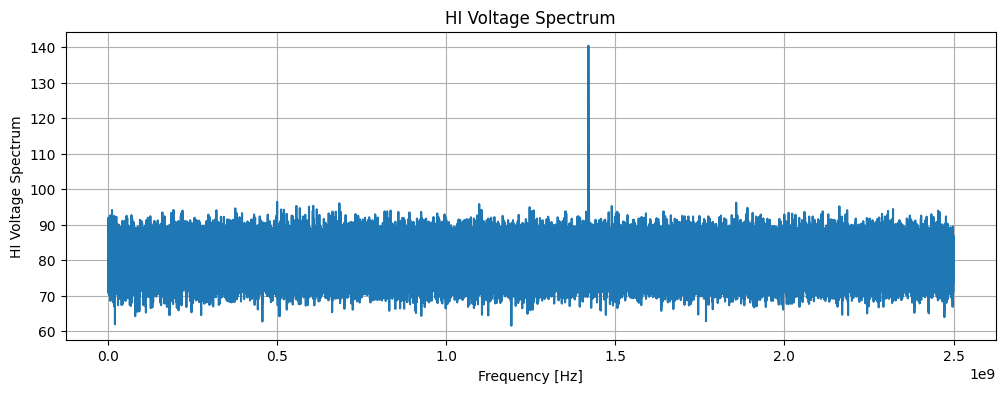

In [6]:
# Plot HI voltage spectrum
hi_voltage_spectrum = data["HI voltage spectrum"].values
frequencies = data["frequencies"].values

plt.figure(figsize=(12, 4))
plt.plot(frequencies, hi_voltage_spectrum)
plt.xlabel("Frequency [Hz]")
plt.ylabel("HI Voltage Spectrum")
plt.title("HI Voltage Spectrum")
plt.grid(True)
plt.show()

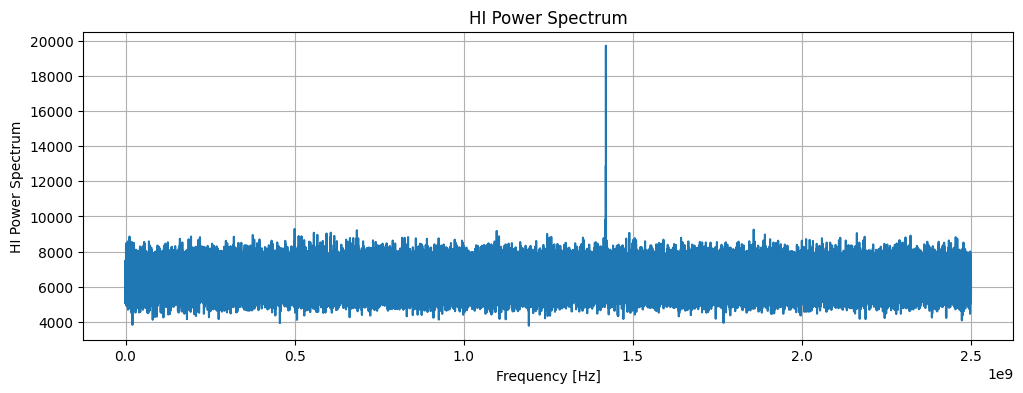

In [15]:
# Plot HI voltage spectrum
hi_voltage_spectrum = data["HI voltage spectrum"].values
frequencies = data["frequencies"].values

hi_power_spectrum = np.abs(hi_voltage_spectrum)**2

plt.figure(figsize=(12, 4))
plt.plot(frequencies, hi_power_spectrum)
plt.xlabel("Frequency [Hz]")
plt.ylabel("HI Power Spectrum")
plt.title("HI Power Spectrum")
plt.grid(True)
plt.show()

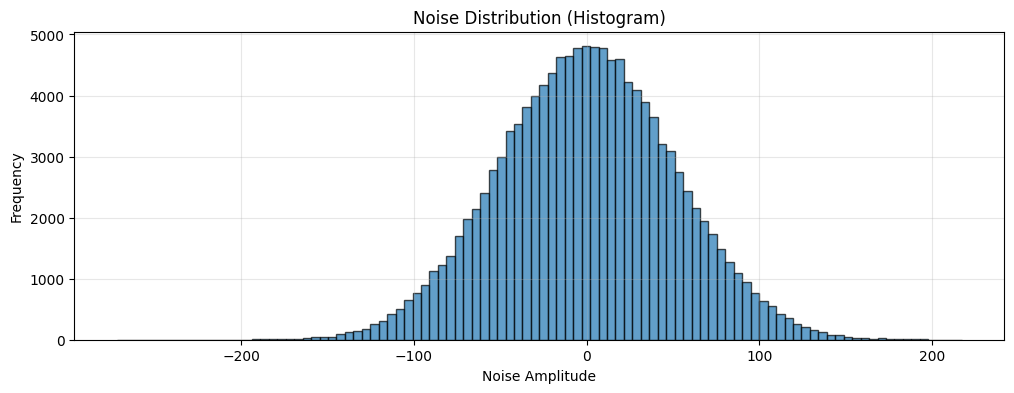

Noise Mean: -0.002697
Noise Std Dev: 50.663137
Noise Min: -272.038425
Noise Max: 217.424170


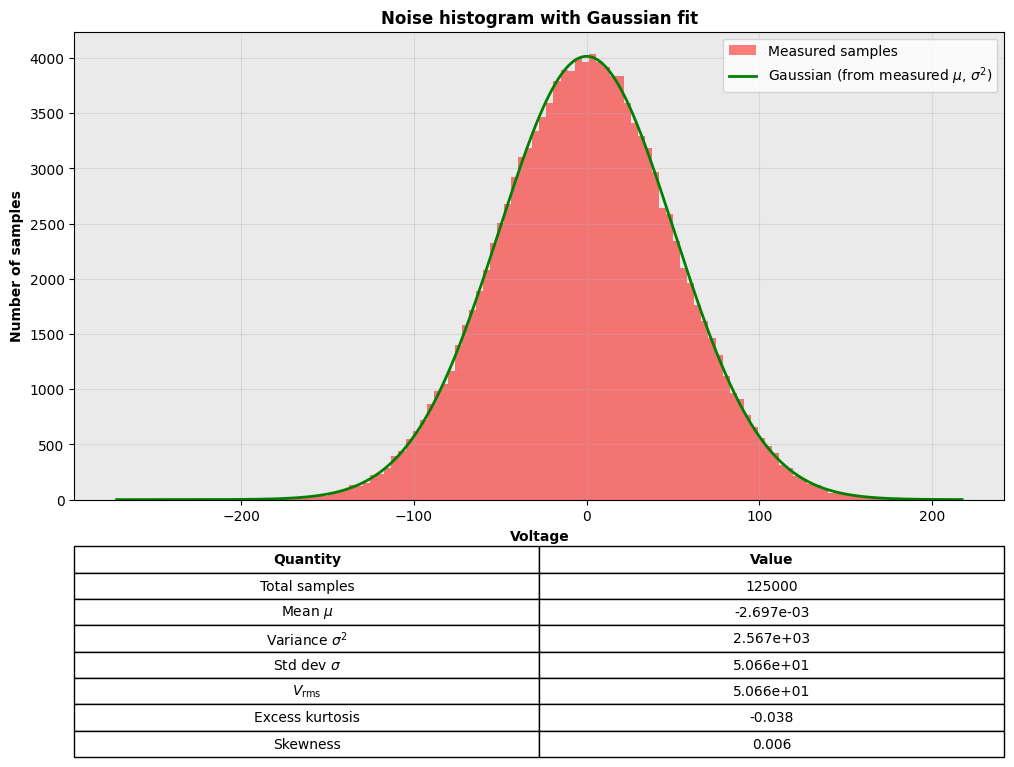

In [13]:
# Calculate and plot noise histogram
# Compute noise as the difference between consecutive samples (high-frequency variations)
noise = np.diff(time_series)

plt.figure(figsize=(12, 4))
plt.hist(noise, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel("Noise Amplitude")
plt.ylabel("Frequency")
plt.title("Noise Distribution (Histogram)")
plt.grid(True, alpha=0.3)
plt.show()

# Print noise statistics
print(f"Noise Mean: {np.mean(noise):.6f}")
print(f"Noise Std Dev: {np.std(noise):.6f}")
print(f"Noise Min: {np.min(noise):.6f}")
print(f"Noise Max: {np.max(noise):.6f}")

# Detailed noise analysis with Gaussian fit

fs = 5e6

# Use the noise we already computed (differences between consecutive samples)
x_all = noise  # noise array from previous cell

# 1) Mean + variance
mu = np.mean(x_all)
var = np.var(x_all, ddof=1)
sigma = np.sqrt(var)
vrms = np.sqrt(np.mean(x_all**2))

# 2) Histogram (counts) + scaled Gaussian
bins = 120

counts, edges = np.histogram(x_all, bins=bins, density=False)
bin_width = edges[1] - edges[0]

# Voltage axis for smooth Gaussian
x_gauss = np.linspace(edges[0], edges[-1], 1000)

# Gaussian PDF using measured mean and variance
gauss_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_gauss - mu) / sigma) ** 2
)

# Scale PDF → expected counts per bin
gauss_counts = gauss_pdf * len(x_all) * bin_width

# Gaussianity metrics
kurtosis_val = kurtosis(x_all, fisher=True, bias=False)
skewness_val = skew(x_all, bias=False)

# Build table
table_rows = [
    ["Total samples", f"{len(x_all):d}"],
    [r"Mean $\mu$", f"{mu:.3e}"],
    [r"Variance $\sigma^2$", f"{var:.3e}"],
    [r"Std dev $\sigma$", f"{sigma:.3e}"],
    [r"$V_{\mathrm{rms}}$", f"{vrms:.3e}"],
    ["Excess kurtosis", f"{kurtosis_val:.3f}"],
    ["Skewness", f"{skewness_val:.3f}"],
]

# Plot + table at bottom
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(x_all, bins=bins, alpha=0.5, color="red", label="Measured samples")
ax.plot(x_gauss, gauss_counts, linewidth=2, color="green",
        label=r"Gaussian (from measured $\mu$, $\sigma^2$)")

ax.set_xlabel("Voltage", weight="semibold")
ax.set_ylabel("Number of samples", weight="semibold")
ax.set_title("Noise histogram with Gaussian fit", weight="semibold")
ax.set_facecolor("#EAEAEA")
ax.grid(True, alpha=0.3)
ax.legend()

# Add table below plot
table = ax.table(
    cellText=table_rows,
    colLabels=["Quantity", "Value"],
    cellLoc="center",
    loc="bottom",
    bbox=[0.0, -0.55, 1.0, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(0.1, 0.1)

# Make room for table
plt.subplots_adjust(bottom=0.1)

# Make column headers bold
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header row
        cell.set_text_props(weight="bold")

# Create figures directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/noise_histogram_gaussian_fit.png", dpi=300, bbox_inches="tight")
plt.show()